In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import keras



train: 60,000
test : 10,000


,0,1,2,3,4,5,6,7,8,9
label,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot


<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32


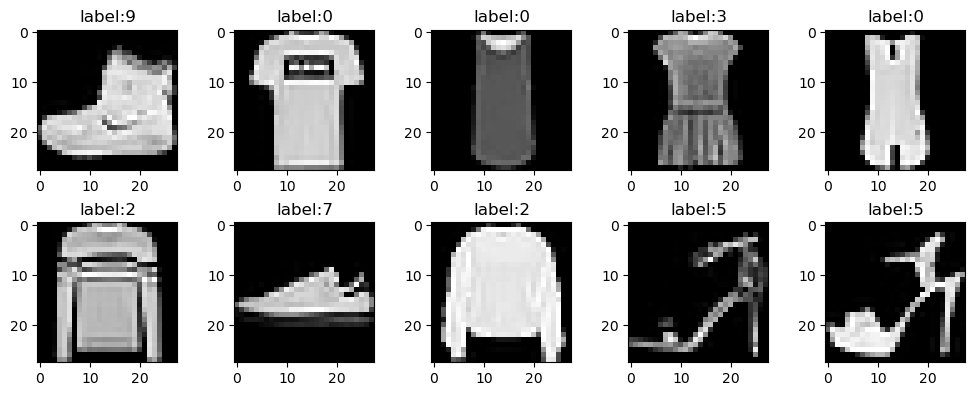

In [3]:
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transform

preprocessing = transform.ToTensor()

fashion_mnist = {}

for split in ['train','test']:
    fashion_mnist[split] =FashionMNIST(
        root='data', train=(split=='train'), download=True, transform=preprocessing)
    print(f'{split:<5}: {len(fashion_mnist[split]):,}')


display(pd.DataFrame({'label':FashionMNIST.classes}).T)
plt.figure(figsize=(10,4))

for i, (sample, label) in zip(range(10),fashion_mnist['train']):

    sample = sample.squeeze()
    print(type(sample), sample.shape, sample.dtype)
    plt.subplot(2,5,i+1)
    plt.imshow(sample, cmap='gray')
    plt.title(f'label:{label}')


plt.tight_layout()
plt.show()


In [4]:
sample, label = fashion_mnist['train'][0]
print(type(sample), sample.shape)
#display(pd.DataFrame({'lable':FashionMNIST}))

<class 'torch.Tensor'> torch.Size([1, 28, 28])


In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)

# 전처리 : 데이터를  numpy 배여롤 변환
X_train = fashion_mnist['train'].data.numpy().reshape(-1,28*28) # flatten 60000, 28, 28 -> 60000 784

X_train = X_train / 255.0 

print(X_train.shape, X_train.dtype, X_train.min(), X_train.max())
y_train = fashion_mnist['train'].targets.numpy()

model.fit(X_train, y_train)
scores = {'train:':model.score(X_train,y_train)}
print(pd.Series(scores).round(4))


(60000, 784) float64 0.0 1.0


KeyboardInterrupt: 

In [6]:
from keras import layers

model = keras.Sequential()
model.add(keras.Input(shape=(1,28,28)))


# vector 
model.add(layers.Flatten())

# hidden layer  
model.add(layers.Dense(512, activation='relu'))

# 출력

model.add(layers.Dense(10, activation='softmax'))

model.summary()

model.compile(loss=keras.losses.SparseCategoricalCrossentropy(),
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])


dataloaders = {}

for split in fashion_mnist.keys():
    dataloaders[split] = torch.utils.data.DataLoader(
        fashion_mnist[split], batch_size=128, shuffle=(split=='train')
        )
    print(f'{split:<5}: {len(dataloaders[split]):,} batches')


history = model.fit(
    dataloaders['train'], epochs=10,
               validation_data=dataloaders['test'],
               
)

# many parameter cuased by overfitting



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

train: 469 batches
test : 79 batches
Epoch 1/10
395/469 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7689 - loss: 0.6718

KeyboardInterrupt: 

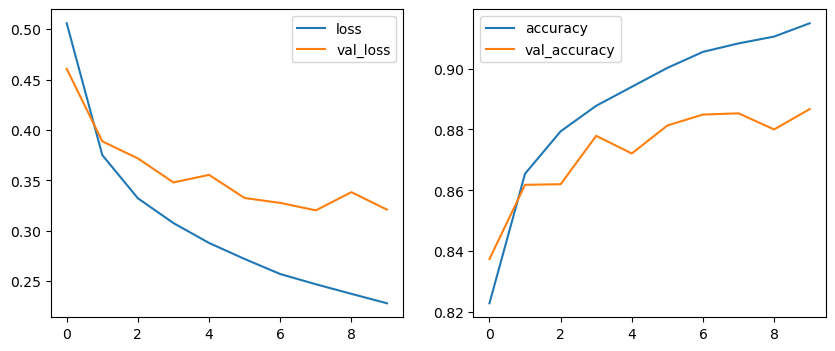

In [ ]:
# overfitting sample 
results = pd.DataFrame(history.history)
results.round(2)

plt.figure(figsize=(10,4))

left = plt.subplot(1,2,1)
results.plot(y=['loss','val_loss'],ax=left)
right = plt.subplot(1,2,2)
results.plot(y=['accuracy','val_accuracy'], ax=right)

plt.show()

In [ ]:
# excute evaluating we considering new data except old test data 
test_result = model.evaluate(dataloaders['test'], return_dict=True)
print(pd.Series(test_result).round(4))


79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8426 - loss: 0.4563
accuracy    0.8369
loss        0.4680
dtype: float64


In [ ]:
X_train, y_train = next(iter(dataloaders['train']))
# 케라스 모델은 자동으로 GPU 탐지 활용, 
print(f'insert data : {X_train.device}')
outputs = model(X_train)
print(outputs.device)

insert data : cpu
cuda:0


In [ ]:
# GPU 가속

x = torch.linspace(0, 1, 5)
print(x.device, x)
assert torch.all( x - x == 0)


x2 = x.to('cuda')
print(x2.device, x2)
assert torch.all(x2 -x2 == 0)

try:
    assert torch.all(x - x2 == 0)
except Exception as e:
    print(e)

cpu tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])
cuda:0 tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000], device='cuda:0')
Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!


In [ ]:
# check training data

all_input=[];all_output = []; all_label = []

for X_batch, y_batch in dataloaders['train']:
    outputs = model.predict(X_batch)
    all_input.append(X_batch)
    all_output.append(outputs)
    all_label.append(y_batch.numpy())


all_input = np.concatenate(all_input, axis=0)
all_output = np.concatenate(all_output, axis=0)
all_label = np.concatenate(all_label, axis=0)

predict = np.argmax(all_output, axis=1)
check = predict == all_label

print(f'{check.sum()}/{len(check)} = {check.mean():.2%}')



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4

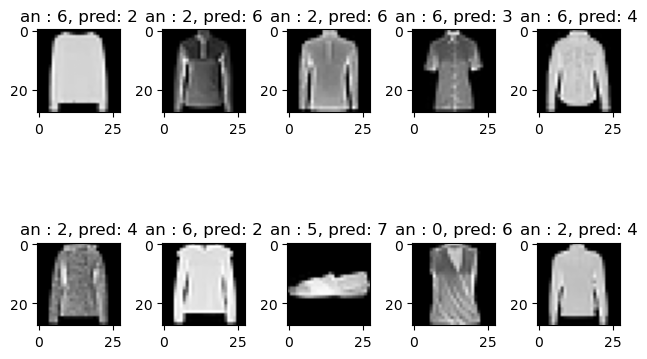

In [ ]:

# wrong answer filtering,  page 282

all_input=[];all_output = []; all_label = []

for X_batch, y_batch in dataloaders['train']:
    outputs = model.predict(X_batch)
    all_input.append(X_batch)
    all_output.append(outputs)
    all_label.append(y_batch.numpy())


all_input = np.concatenate(all_input, axis=0)
all_output = np.concatenate(all_output, axis=0)
all_label = np.concatenate(all_label, axis=0)

predict = np.argmax(all_output, axis=1)
check = predict == all_label

print(f'{check.sum()}/{len(check)} = {check.mean():.2%}')


# wrong answer
wrongfilter = np.logical_not(check)

for i, xi, yi, pi in zip (range(10), all_input[wrongfilter], all_label[wrongfilter], predict[wrongfilter]):
    #print(f'answer : {yi}, predict: {pi}')
    plt.subplot(2,5,i+1)
    plt.imshow(xi.squeeze(),cmap='gray')
    plt.title(f'an : {yi}, pred: {pi}')
    

plt.tight_layout()
plt.show()







In [ ]:
from keras import layers

model = keras.Sequential()
model.add(keras.Input(shape=(1,28,28)))


# vector 
model.add(layers.Flatten())

# hidden layer  

# many parameter cuased by overfitting 512 -> 256 
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(256, activation='relu'))

# 출력

model.add(layers.Dense(10, activation='softmax'))

model.summary()

model.compile(loss=keras.losses.SparseCategoricalCrossentropy(),
              optimizer=keras.optimizers.Adam(), # learning rate 확인
              metrics=['accuracy'])


dataloaders = {}

for split in fashion_mnist.keys():
    dataloaders[split] = torch.utils.data.DataLoader(
        fashion_mnist[split], batch_size=128, shuffle=(split=='train')
        )
    print(f'{split:<5}: {len(dataloaders[split]):,} batches')


history = model.fit(
    dataloaders['train'], epochs=10,
               validation_data=dataloaders['test'],
               
)



Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_16 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

train: 469 batches
test : 79 batches
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.7694 - loss: 0.6684 - val_accuracy: 0.8447 - val_loss: 0.4234
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.8651 - loss: 0.3701 - val_accuracy: 0.8584 - val_loss: 0.3871
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8803 - loss: 0.3263 - val_accuracy: 0.8626 - val_loss: 0.3774
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8929 - loss: 0.2958 - val_accuracy: 0.8740 - val_loss: 0.3511
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.8952 - loss: 0.2822 - val_accuracy: 0.8797 - val_loss: 0.3333
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9010 - loss: 0.2643 - val_accuracy: 0.8816 - val_loss: 0.3320
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9059 - loss: 0.2511 - val_accuracy: 0.8763 - val_loss: 0.3417
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step

In [ ]:

## 합성곱 신경망
## convolutional Neural Network

import keras
from keras import layers

keras.backend.clear_session()

model = keras.Sequential()

model.add(keras.Input(shape=(1,28,28))) # channels first 형식 : ( 채널 높이 너비 ) 

# hidden 반복 패턴으로 관리 가능 

for units in [32,64]:
    model.add(layers.Conv2D(units, kernel_size=3, activation='relu', data_format='channels_first'))
    model.add(layers.MaxPooling2D(pool_size=2, data_format='channels_first'))


# output
model.add(layers.Flatten())
model.add(layers.Dense(10, activation='softmax'))

model.summary()



model.compile(loss=keras.losses.SparseCategoricalCrossentropy(),
              optimizer=keras.optimizers.Adam(learning_rate=1e-3), # learning rate 확인
              metrics=['accuracy'])

dataloaders = {}

for split in fashion_mnist.keys():
    dataloaders[split] = torch.utils.data.DataLoader(
        fashion_mnist[split], batch_size=128, shuffle=(split=='train')
        )
    print(f'{split:<5}: {len(dataloaders[split]):,} batches')


history = model.fit(
    dataloaders['train'], epochs=10,
               validation_data=dataloaders['test'],
               
)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 26, 26)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 13, 13)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 11, 11)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 5, 5)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

train: 469 batches
test : 79 batches
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.6935 - loss: 0.8797 - val_accuracy: 0.8435 - val_loss: 0.4401
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.8559 - loss: 0.4110 - val_accuracy: 0.8553 - val_loss: 0.3957
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.8737 - loss: 0.3540 - val_accuracy: 0.8705 - val_loss: 0.3593
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.8837 - loss: 0.3238 - val_accuracy: 0.8799 - val_loss: 0.3384
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.8931 - loss: 0.2999 - val_accuracy: 0.8808 - val_loss: 0.3283
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9004 - loss: 0.2789 - val_accuracy: 0.8932 - val_loss: 0.3066
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9021 - loss: 0.2694 - val_accuracy: 0.8922 - val_loss: 0.3076
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step

In [ ]:
## cat and dog learning 
## include path 


from pathlib import Path
folder = Path('/workspace/cats_dogs_small')

assert folder.is_dir(), f'{folder} is not'

for sub in folder.iterdir():
    print(sub)



files = {}
for split in ['train', 'validation', 'test']:
    files[split] = list((folder / split).glob('**/*.jpg'))
    print(f'{split:<10}: {len(files[split]):,} files')





/workspace/cats_dogs_small/test
/workspace/cats_dogs_small/train
/workspace/cats_dogs_small/validation
train     : 2,000 files
validation: 1,000 files
test      : 2,000 files


In [ ]:
# image 
import PIL.Image as Image

sample, label = files['train'][0]
print(sample)
print(sample.name) # file full name
print(sample.stem) # file name 


with Image.open(sample) as img:
    print(type(img), img.size, img.mode)
    # with inner block image just close , copy data
    sample = img.copy()


display(sample)



TypeError: cannot unpack non-iterable PosixPath object

test      : 2,000 samples
train     : 2,000 samples
validation: 1,000 samples
<class 'PIL.Image.Image'> (499, 375)
lable: dog
unsupported operand type(s) for -: 'Image' and 'Image'


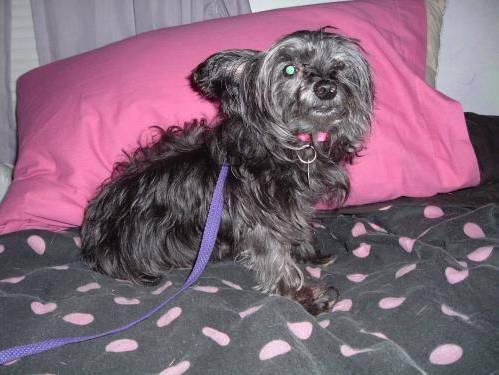

In [ ]:
%run catdog-me.py


dataset = {}

for sub in folder.iterdir():
    split = sub.name
    dataset[split] = CatDogDataset(sub)
    print(f'{split:<10}: {len(dataset[split]):,} samples')


sample, target = dataset['train'][1000]
print(type(sample), sample.size)
print(f"lable: {'cat' if labels == 0 else 'dog'}")


# imame is not calculating

try:
    sample - sample
except Exception as e:
    print(e)

display(sample)



test      : 2,000 samples
train     : 2,000 samples
validation: 1,000 samples
<class 'torch.Tensor'> <built-in method size of Tensor object at 0x77dc8a7249f0>
lable: dog


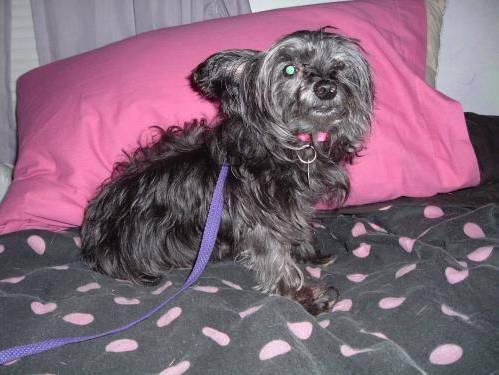

In [ ]:
import torchvision.transforms as transforms


%run catdog-me.py


preprocession = transforms.Compose({
    transforms.Resize((180,180)),
    transforms.ToTensor()
})

dataset = {}

for sub in folder.iterdir():
    split = sub.name
    dataset[split] = CatDogDataset(sub,  transform=preprocessing) # transforms.ToTensor()
    print(f'{split:<10}: {len(dataset[split]):,} samples')


sample, labels = dataset['train'][1000]
print(type(sample), sample.size)
print(f"lable: {'cat' if label == 0 else 'dog'}")


# imame is not calculating

try:
    sample - sample
except Exception as e:
    print(e)

display(transforms.ToPILImage()(sample))


In [ ]:
import torch

%run catdog-me.py

preprocession = transforms.Compose({
    transforms.Resize((180,180)),
    transforms.ToTensor()
})

dataloaders = {}

for split in dataset.keys():
    dataloaders[split] = torch.utils.data.DataLoader(dataset[split], batch_size=32, shuffle=(split=='train'))
    print(f'{split:<10}: {len(dataloaders[split]):,} batches')


#for X_batch, y_batch in dataloaders['train']:
#    print(X_batch.shape, y_batch.shape)
#    break


test      : 63 batches
train     : 63 batches
validation: 32 batches


In [ ]:
from keras import layers

keras.backend.set_image_data_format('channels_last') # data format default setting 

model = keras.Sequential()
model.add(keras.Input(shape=(3,180,180))) # channel first format = channel height weight

model.add(layers.Permute((2,3,1))) # channel last format =  height weight channel


## hidden
for units in [32,64,128,256]:
    model.add(keras.layers.Conv2D(units, kernel_size=3, activation='relu'))
    model.add(keras.layers.MaxPooling2D(pool_size=2))


model.add(keras.layers.Conv2D(256, kernel_size=3, activation='relu'))
## output 
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(1, activation='sigmoid')) # 이진 분류 출력

model.summary()

model.compile(
    # binary problem
    loss=keras.losses.BinaryCrossentropy(),
    # 학습률 튜닝을 줄이기 위한 자동 학습률 조정 가능한 RMSporp 사용
    optimizer=keras.optimizers.RMSprop(), 
    metrics=['accuracy'])


%run train_catdog_me.py


history = model.fit(
    dataloaders['train'], epochs=30,
               validation_data=dataloaders['validation'],
               callbacks=[
                   keras.callbacks.ModelCheckpoint(
                       'catdog.keras',save_best_only=True, monitor='val_loss',
                   ),
                   #keras.callbacks.EarlyStopping(
                   #    monitor='val_loss', patience=5, restore_best_weights=True,
                   #)
               ]
               
)



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ permute_6 (Permute)             │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

test      : 2,000 samples
train     : 2,000 samples
validation: 1,000 samples
test      : 63 batches
train     : 63 batches
validation: 32 batches
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - accuracy: 0.5037 - loss: 0.7554 - val_accuracy: 0.5010 - val_loss: 0.6917
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.5209 - loss: 0.6934 - val_accuracy: 0.5130 - val_loss: 0.6889
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.5663 - loss: 0.6858 - val_accuracy: 0.6250 - val_loss: 0.6669
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6204 - loss: 0.6584

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bef63ea64d0>
Traceback (most recent call last):
  File "/home/me/miniforge3/envs/pytorch/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/home/me/miniforge3/envs/pytorch/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
  File "/home/me/miniforge3/envs/pytorch/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bef63ea64d0>
Traceback (most recent call last):
  File "/home/me/miniforge3/envs/pytorch/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/home/me/miniforge3/envs/pytorch/lib/python3.10/s

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - accuracy: 0.6204 - loss: 0.6584 - val_accuracy: 0.6220 - val_loss: 0.6468
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.6594 - loss: 0.6233 - val_accuracy: 0.6260 - val_loss: 0.7162
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.6844 - loss: 0.5873 - val_accuracy: 0.6460 - val_loss: 0.6586
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.7124 - loss: 0.5714 - val_accuracy: 0.6780 - val_loss: 0.6360
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - accuracy: 0.7257 - loss: 0.5523 - val_accuracy: 0.6680 - val_loss: 0.6293
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.7462 - loss: 0.5319 - val_accuracy: 0.7190 - val_loss: 0.5404
Epoch 10/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.7747 - loss: 0.4676 - val_accuracy: 0.7030 - val_loss: 0.5739
Epoch 11/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.7821 - loss: 0.4581 - val_accuracy: 0.6

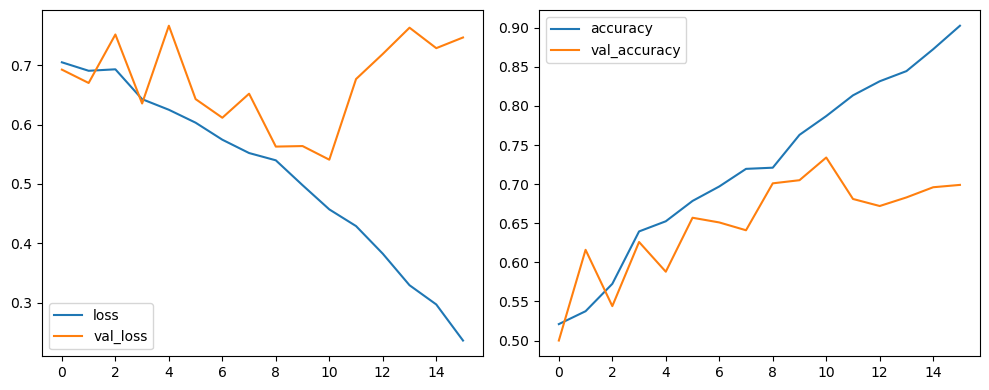

In [19]:
train_results = pd.DataFrame(history.history)

plt.figure(figsize=(10,4))
left =plt.subplot(1,2,1)

train_results.plot(y=['loss','val_loss'], ax =left)

right = plt.subplot(1,2,2)

train_results.plot(y=['accuracy','val_accuracy'], ax=right)
plt.tight_layout()
plt.show()

In [20]:
# best 모델을 불러와서 측정합니다. 
model = keras.models.load_model('catdog.keras')
test_result = model.evaluate(dataloaders['test'], return_dict=True)
print(pd.Series(test_result).round(4))

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.7405 - loss: 0.5625
accuracy    0.7195
loss        0.5764
dtype: float64


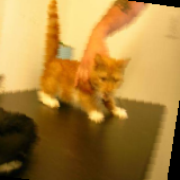

In [ ]:
# 데이터 증식

preprocessing = transforms.Compose([
    transforms.Resize((180,180)),
    transforms.ToTensor()
])

train_preprocessing = transforms.Compose([
    
    transforms.Resize((180,180)), 
    # 좌우반전
    transforms.RandomHorizontalFlip(),
    # 20도 범위 내 랜덤 진입
    transforms.RandomRotation(20),
    #랜덤 크롭 및 리사이즈
    transforms.RandomResizedCrop((180,180), scale=(0.8,1.0)),
    transforms.ToTensor()
])


for split in ['train', 'validation', 'test']:
    transform = train_preprocessing if split == 'train' else preprocessing
    dataset[split] = CatDogDataset( folder / 'train', transform=transform)


    # 매번 다른 결과 호출 
sample, label = dataset['train'][0]
display(transforms.ToPILImage()(sample))



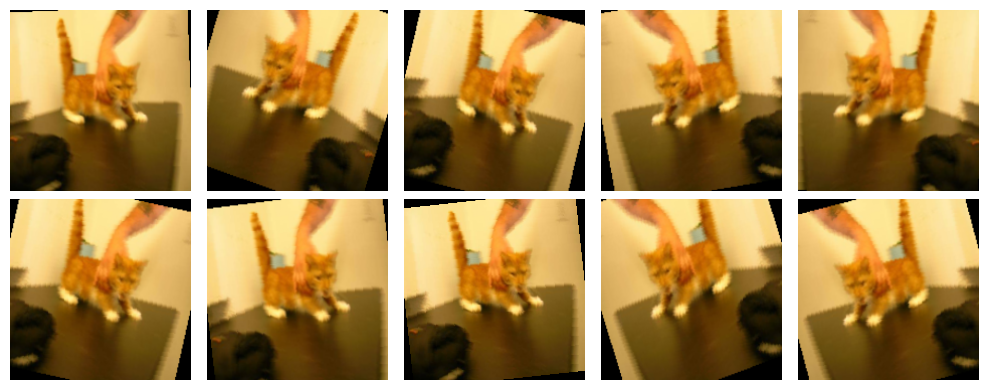

In [26]:
plt.figure(figsize=(10,4))
for i in range(10):
    # 매번 다른 결과 호출 
    sample, label = dataset['train'][0]
    plt.subplot(2,5,i+1)
    plt.imshow(sample.permute(1,2,0))
    plt.axis('off')


    #display(transforms.ToPILImage()(sample))
plt.tight_layout()
plt.show()



In [28]:
from keras import layers

keras.backend.clear_session()
# keras.backend.set_image_data_format('channels_last')

model = keras.Sequential()
model.add(keras.Input(shape=(3, 180, 180))) # channels first 형식
# (C, H, W) -> (H, W, C)로 변환하는 레이어
model.add(layers.Permute((2, 3, 1))) # (B, C, H, W) -> (B, H, W, C)
# 은닉층
for units in [32, 64, 128, 256]:
    model.add(layers.Conv2D(
        units, kernel_size=3, activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=2))

model.add(layers.Conv2D(256, kernel_size=3, activation='relu'))
# 출력층
model.add(layers.Flatten())
model.add(layers.Dense(1, activation='sigmoid')) # 이진 분류 출력

model.summary()

model.compile(
    # 이진 분류 문제이므로, BinaryCrossentropy 손실 함수를 사용
    loss=keras.losses.BinaryCrossentropy(),
    # 학습률 튜닝을 줄이기 위해 자동 학습률 조정 가능한 RMSprop 사용
    optimizer=keras.optimizers.RMSprop(),
    metrics=['accuracy']
)

%run catdog_me.py
dataloaders = get_dataloaders(
    dataset, batch_size=32, num_workers=8)

history = model.fit(
    dataloaders['train'],
    validation_data=dataloaders['validation'],
    epochs=100,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            'catdog.keras', save_best_only=True, monitor='val_loss'),
    ]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ permute (Permute)               │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

test      : 63 batches
train     : 63 batches
validation: 63 batches
Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.9716 - loss: 0.2009 - val_accuracy: 0.5000 - val_loss: 5.9684
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.8482 - loss: 1.0926 - val_accuracy: 0.5000 - val_loss: 5.7535
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.8383 - loss: 1.0621 - val_accuracy: 0.5000 - val_loss: 5.7009
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.7972 - loss: 1.0670 - val_accuracy: 0.5000 - val_loss: 5.7013
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.8348 - loss: 1.0595 - val_accuracy: 0.5000 - val_loss: 5.3768
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.7873 - loss: 1.0444 - val_accuracy: 0.5000 - val_loss: 5.4185
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.7873 - loss: 1.0631 - val_accuracy: 0.5000 - val_loss: 5.3292
Epoch 8/100
63/63 ━━━━━━━━━━━━

In [ ]:
model = keras.models.load_model('catdog.keras')
test_results = model.evaluate(dataloaders['test'], return_dict=True)
test_results = pd.Series(test_results).round(4)

train_results = get_train_results(history)

## pre training model

In [32]:
from keras.applications import vgg16

model = vgg16.VGG16(weights='imagenet') # image count : 14m, size : 30G

model.summary()


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

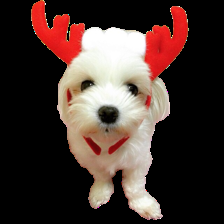

(224, 224, 3) uint8 0 255


In [ ]:
from PIL import Image

with Image.open('/workspace/data/mozzi.png') as img:
    img = img.resize((224,224)).convert('RGB')
    sample = img.copy()

display(sample)

x1 = np.array(sample)

s1 = vgg16.preprocess_input(x1) #  구격임

print(x1.shape, x1.dtype, x1.min(), x1.max())




In [38]:

outputs = model.predict(np.array([x1]))
print(type(outputs), outputs.shape, outputs.dtype)

predict, 확률 = np.argmax(outputs, axis=1), np.max(outputs, axis=1)

print(f'pred : {predict[0]}, prob :{확률[0]:.2%}')

pd.DataFrame(vgg16.decode_predictions(outputs, top=3)[0]).round(2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
<class 'numpy.ndarray'> (1, 1000) float32
pred : 850, prob :33.90%


,0,1,2
0,n04399382,teddy,0.34
1,n02085936,Maltese_dog,0.18
2,n03944341,pinwheel,0.12
